In [2]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings(action="ignore")
from tensorflow.keras.applications import VGG19, ResNet50
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import time
from sklearn.metrics import roc_curve, auc


In [3]:
# Paths to your dataset
healthy_dirs = [
    r'DS/input/Osteoporosis Knee X-ray/normal',
    r'DS/input/osteoporosis-knee-xray-dataset/normal/normal',
    r'DS/input/Osteoporosis Knee Dataset/Normal',
    r'DS/input/Osteoporosis/normal'
]

osteoporosis_dirs = [
    r'DS/input/Osteoporosis Knee X-ray/osteoporosis',
    r'DS/input/osteoporosis-knee-xray-dataset/osteoporosis/osteoporosis',
    r'DS/input/Osteoporosis Knee Dataset/Osteoporosis',
    r'DS/input/Osteoporosis/osteoporosis'
]

# Dataset preparation
filepaths, labels = [], []
dict_lists = [healthy_dirs, osteoporosis_dirs]
class_labels = ['Healthy', 'Osteoporosis']

for i, dir_list in enumerate(dict_lists):
    for dir in dir_list:
        flist = os.listdir(dir)
        for f in flist:
            fpath = os.path.join(dir, f)
            filepaths.append(fpath)
            labels.append(class_labels[i])

Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")
df = pd.concat([Fseries, Lseries], axis=1)

# Splitting dataset
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.3, random_state=42)
val_set, _ = train_test_split(test_set, test_size=0.5, random_state=42)  # Further split for validation

# Image Data Generator
image_gen = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg19.preprocess_input)
train = image_gen.flow_from_dataframe(dataframe=train_set, x_col="filepaths", y_col="labels",
                                      target_size=(224, 224),
                                      color_mode='rgb',
                                      class_mode="categorical",
                                      batch_size=4,
                                      shuffle=True)
test = image_gen.flow_from_dataframe(dataframe=test_set, x_col="filepaths", y_col="labels",
                                     target_size=(224, 224),
                                     color_mode='rgb',
                                     class_mode="categorical",
                                     batch_size=4,
                                     shuffle=False)
val = image_gen.flow_from_dataframe(dataframe=val_set, x_col="filepaths", y_col="labels",
                                    target_size=(224, 224),
                                    color_mode='rgb',
                                    class_mode="categorical",
                                    batch_size=4,
                                    shuffle=False)

# Model Creation Function
def create_model(model_type):
    if model_type == 'VGG19':
        base_model = VGG19(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
    elif model_type == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
    else:
        raise ValueError("Unsupported model type")
    
    x = base_model.output
    x = Flatten()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(2, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    
    for layer in base_model.layers:
        layer.trainable = False
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

Found 1101 validated image filenames belonging to 2 classes.
Found 472 validated image filenames belonging to 2 classes.
Found 236 validated image filenames belonging to 2 classes.


In [4]:
# Create and train VGG19 and ResNet50 models
vgg19_model = create_model('VGG19')
resnet50_model = create_model('ResNet50')

In [5]:
print("Training VGG19")
vgg19_history = vgg19_model.fit(train, epochs=10, validation_data=val, verbose=1)

Training VGG19
Epoch 1/10


2024-03-30 17:37:01.927491: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


276/276 [==============================] - 134s 483ms/step - loss: 44.3023 - accuracy: 0.7302 - val_loss: 7.8547 - val_accuracy: 0.8347
Epoch 2/10
276/276 [==============================] - 133s 481ms/step - loss: 9.3967 - accuracy: 0.8401 - val_loss: 3.2912 - val_accuracy: 0.8559
Epoch 3/10
276/276 [==============================] - 134s 486ms/step - loss: 4.1413 - accuracy: 0.8656 - val_loss: 1.9465 - val_accuracy: 0.8644
Epoch 4/10
276/276 [==============================] - 128s 465ms/step - loss: 1.6787 - accuracy: 0.9137 - val_loss: 1.5175 - val_accuracy: 0.9025
Epoch 5/10
276/276 [==============================] - 127s 460ms/step - loss: 1.3023 - accuracy: 0.9146 - val_loss: 1.3134 - val_accuracy: 0.8898
Epoch 6/10
276/276 [==============================] - 127s 459ms/step - loss: 1.5399 - accuracy: 0.9010 - val_loss: 1.2977 - val_accuracy: 0.8898
Epoch 7/10
276/276 [==============================] - 127s 459ms/step - loss: 1.8790 - accuracy: 0.8865 - val_loss: 2.6407 - val_accur

In [6]:
print("\nTraining ResNet50")
resnet50_history = resnet50_model.fit(train, epochs=10, validation_data=val, verbose=1)


Training ResNet50
Epoch 1/10
276/276 [==============================] - 82s 292ms/step - loss: 40.8742 - accuracy: 0.7266 - val_loss: 11.2791 - val_accuracy: 0.8051
Epoch 2/10
276/276 [==============================] - 81s 294ms/step - loss: 6.6270 - accuracy: 0.8383 - val_loss: 3.6023 - val_accuracy: 0.8305
Epoch 3/10
276/276 [==============================] - 81s 293ms/step - loss: 2.4341 - accuracy: 0.8692 - val_loss: 1.7847 - val_accuracy: 0.8686
Epoch 4/10
276/276 [==============================] - 81s 292ms/step - loss: 0.8208 - accuracy: 0.9155 - val_loss: 1.4304 - val_accuracy: 0.8602
Epoch 5/10
276/276 [==============================] - 81s 295ms/step - loss: 0.5805 - accuracy: 0.9173 - val_loss: 0.8690 - val_accuracy: 0.8814
Epoch 6/10
276/276 [==============================] - 81s 294ms/step - loss: 0.5323 - accuracy: 0.8974 - val_loss: 1.6401 - val_accuracy: 0.8686
Epoch 7/10
276/276 [==============================] - 81s 294ms/step - loss: 0.7328 - accuracy: 0.9083 - val_

In [7]:
# Evaluate and compare the models
vgg19_loss, vgg19_accuracy = vgg19_model.evaluate(test, verbose=1)
resnet50_loss, resnet50_accuracy = resnet50_model.evaluate(test, verbose=1)

print(f"VGG19 Test Accuracy: {vgg19_accuracy*100:.2f}%")
print(f"ResNet50 Test Accuracy: {resnet50_accuracy*100:.2f}%")

118/118 [==============================] - 17s 145ms/step - loss: 1.0823 - accuracy: 0.8369
VGG19 Test Accuracy: 90.47%
ResNet50 Test Accuracy: 83.69%


118/118 [==============================] - 17s 145ms/step


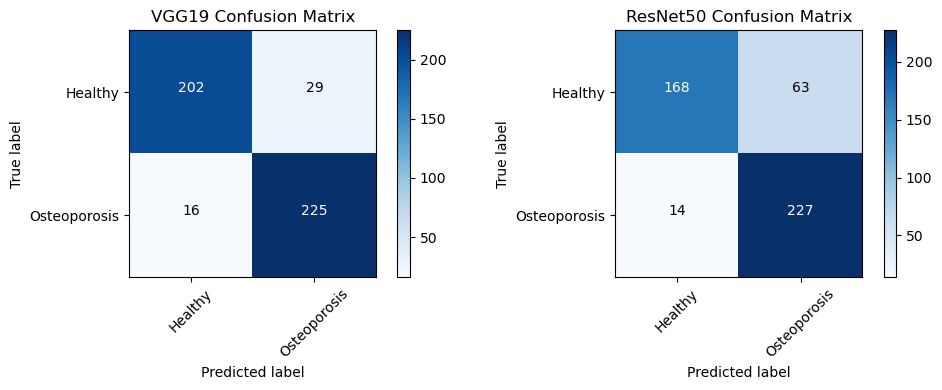

In [21]:
import itertools

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

# Generate predictions and confusion matrix for each model
vgg19_preds = vgg19_model.predict(test, verbose=1)
resnet50_preds = resnet50_model.predict(test, verbose=1)

vgg19_cm = confusion_matrix(test.classes, np.argmax(vgg19_preds, axis=1))
resnet50_cm = confusion_matrix(test.classes, np.argmax(resnet50_preds, axis=1))

# Plotting
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plot_confusion_matrix(vgg19_cm, classes=test.class_indices.keys(), title='VGG19 Confusion Matrix')

plt.subplot(1, 2, 2)
plot_confusion_matrix(resnet50_cm, classes=test.class_indices.keys(), title='ResNet50 Confusion Matrix')
plt.show()


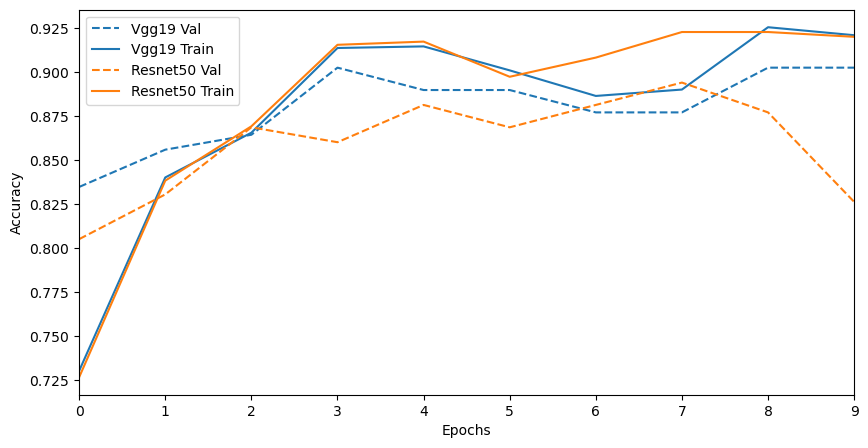

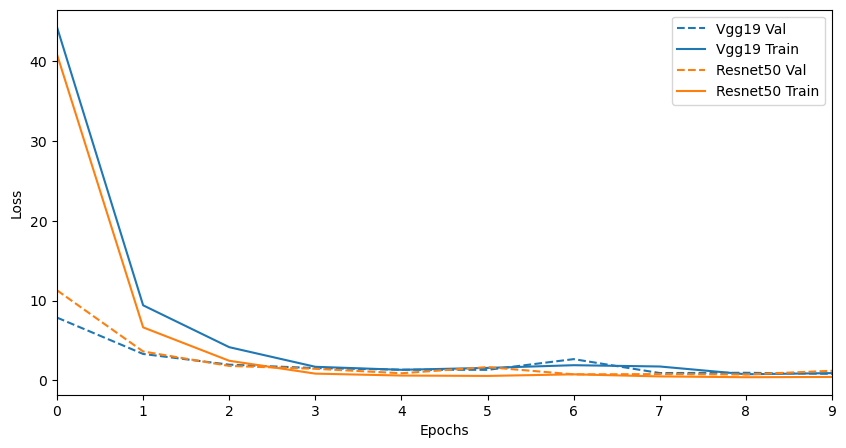

In [22]:
def plot_history(histories, key='accuracy'):
    plt.figure(figsize=(10, 5))

    for name, history in histories:
        val = plt.plot(history.epoch, history.history['val_'+key],
                       '--', label=name.title()+' Val')
        plt.plot(history.epoch, history.history[key], color=val[0].get_color(),
                 label=name.title()+' Train')

    plt.xlabel('Epochs')
    plt.ylabel(key.replace('_', ' ').title())
    plt.legend()

    plt.xlim([0, max(history.epoch)])

plot_history([('VGG19', vgg19_history), ('ResNet50', resnet50_history)], key='accuracy')
plot_history([('VGG19', vgg19_history), ('ResNet50', resnet50_history)], key='loss')


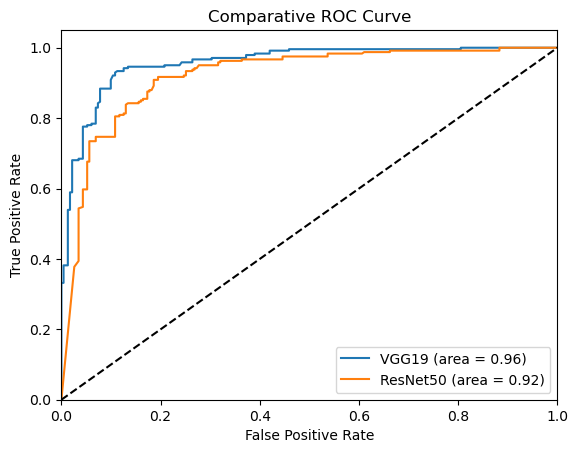

In [23]:
# Calculate ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, model_preds in enumerate([vgg19_preds, resnet50_preds]):
    fpr[i], tpr[i], _ = roc_curve(test.classes, model_preds[:, 1])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curves
plt.figure()
plt.plot(fpr[0], tpr[0], label='VGG19 (area = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], label='ResNet50 (area = %0.2f)' % roc_auc[1])
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparative ROC Curve')
plt.legend(loc="lower right")
plt.show()


In [26]:
# saving the model till the process!

In [27]:
vgg19_model.save('vgg19_pre_finetuning.h5')
resnet50_model.save('resnet50_pre_finetuning.h5')

In [29]:
# Now we are moving to increase the accuracy of VGG19, so we are performing fine-tunning

In [30]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Define your callbacks
checkpoint = ModelCheckpoint('vgg19_finetuned_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7, verbose=1)

# Fine-tuning steps
for step in range(1, 6):  # Example: 5 steps of fine-tuning
    # Determine the number of layers to unfreeze
    layers_to_unfreeze = step * 4  # Example strategy: Unfreeze 4 more layers with each step
    
    # Unfreeze the top N layers
    for layer in vgg19_model.layers[-layers_to_unfreeze:]:
        layer.trainable = True
    
    # Compile the model with a reduced learning rate
    learning_rate = 1e-5 / (10 ** step)  # Decrease learning rate with each step
    vgg19_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
    
    print(f"Step {step}: Training with top {layers_to_unfreeze} layers unfrozen.")
    
    # Train the model
    history = vgg19_model.fit(train, epochs=5,  # Adjust epochs based on your dataset size and complexity
                              validation_data=val,
                              callbacks=[checkpoint, early_stopping, reduce_lr],
                              verbose=1)
    
    # Evaluate model performance after this fine-tuning step
    loss, accuracy = vgg19_model.evaluate(test, verbose=1)
    print(f"After step {step} Fine-tuning - Test Loss: {loss:.4f}, Test Accuracy: {accuracy*100:.2f}%")


Step 1: Training with top 4 layers unfrozen.
Epoch 1/5
276/276 [==============================] - ETA: 0s - loss: 0.3296 - accuracy: 0.9264
Epoch 1: val_accuracy improved from -inf to 0.89831, saving model to vgg19_finetuned_best.h5
276/276 [==============================] - 131s 473ms/step - loss: 0.3296 - accuracy: 0.9264 - val_loss: 0.7947 - val_accuracy: 0.8983 - lr: 1.0000e-06
Epoch 2/5
276/276 [==============================] - ETA: 0s - loss: 0.3799 - accuracy: 0.9264
Epoch 2: val_accuracy did not improve from 0.89831
276/276 [==============================] - 130s 469ms/step - loss: 0.3799 - accuracy: 0.9264 - val_loss: 0.7913 - val_accuracy: 0.8983 - lr: 1.0000e-06
Epoch 3/5
276/276 [==============================] - ETA: 0s - loss: 0.2853 - accuracy: 0.9455
Epoch 3: val_accuracy improved from 0.89831 to 0.90254, saving model to vgg19_finetuned_best.h5
276/276 [==============================] - 129s 469ms/step - loss: 0.2853 - accuracy: 0.9455 - val_loss: 0.7899 - val_accuracy

In [31]:
# Predictions and True Labels
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Ensure the test generator is not shuffling data for evaluation
test.reset()

# Predict the test set
predictions = vgg19_model.predict(test, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = test.classes
class_labels = list(test.class_indices.keys())  # Get class labels from the test generator


118/118 [==============================] - 44s 372ms/step


In [32]:
# Classification Report
print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
print("Confusion Matrix:")
print(cm)


Classification Report:
              precision    recall  f1-score   support

     Healthy       0.93      0.88      0.91       231
Osteoporosis       0.89      0.94      0.91       241

    accuracy                           0.91       472
   macro avg       0.91      0.91      0.91       472
weighted avg       0.91      0.91      0.91       472

Confusion Matrix:
[[204  27]
 [ 15 226]]


118/118 [==============================] - 43s 364ms/step


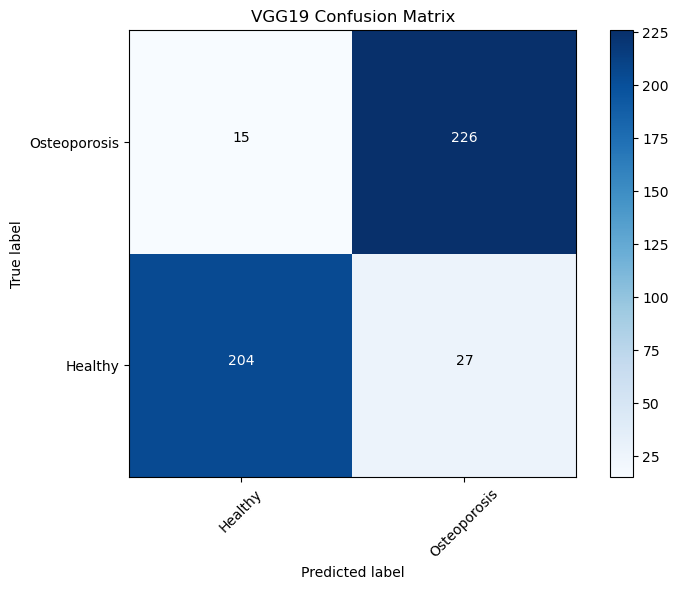

In [38]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from keras.preprocessing.image import ImageDataGenerator

# Assuming 'test' is your testing dataset generator
# Load your model (example: vgg19_model = load_model('path_to_your_model.h5'))

# Function to plot confusion matrix with adjustments for axes
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.ylim(top=cm.shape[0]-0.5, bottom=-0.5)  # Adjusted to ensure the full display of the confusion matrix

# Assuming you have a test dataset 'test' and a model 'vgg19_model'
# You might need to adjust this part based on how you've prepared 'test' and 'vgg19_model'
vgg19_preds = vgg19_model.predict(test, verbose=1)
vgg19_cm = confusion_matrix(test.classes, np.argmax(vgg19_preds, axis=1))

# Plotting for VGG19
plt.figure(figsize=(8, 6))
plot_confusion_matrix(vgg19_cm, classes=list(test.class_indices.keys()), title='VGG19 Confusion Matrix')
plt.show()


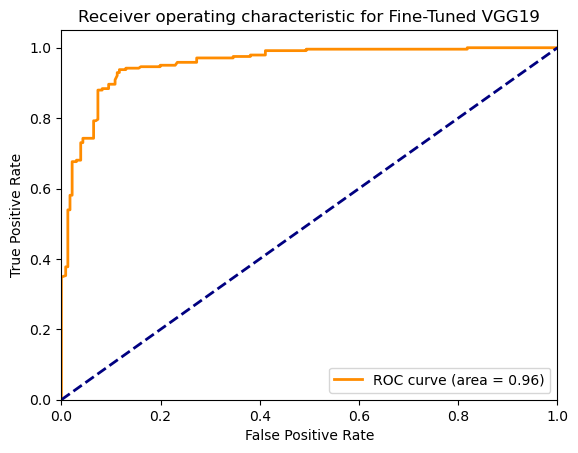

In [39]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have predictions and true_classes as defined previously
# Here, focusing on one class, typically the positive class
fpr, tpr, thresholds = roc_curve(true_classes, predictions[:, 1])  # change depending on your positive class index
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic for Fine-Tuned VGG19')
plt.legend(loc="lower right")
plt.show()


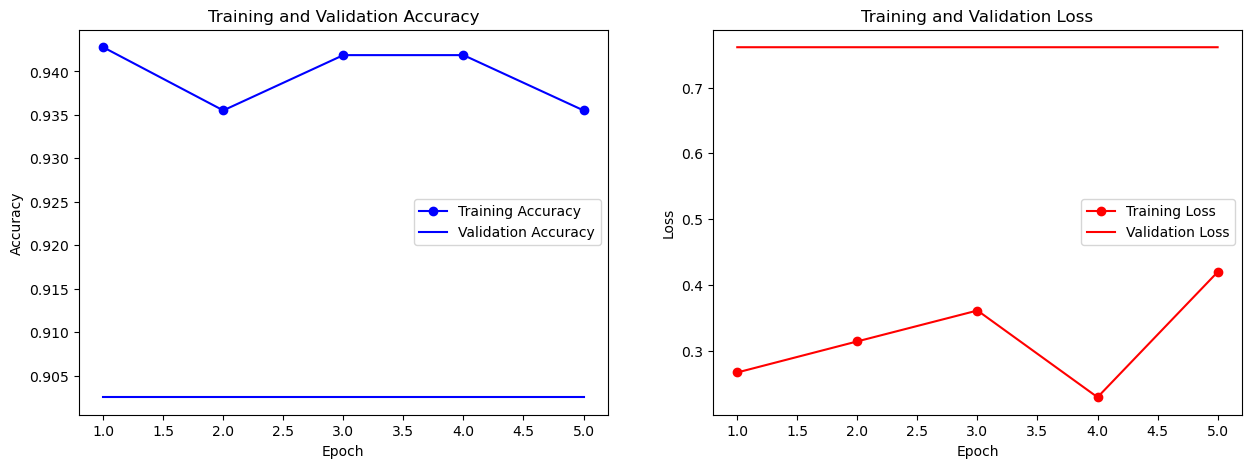

In [42]:
import matplotlib.pyplot as plt

# Assuming 'history' contains the history object from the last iteration of fine-tuning
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Set up the matplotlib figure size
plt.figure(figsize=(15, 5))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')  # X-axis label
plt.ylabel('Accuracy')  # Y-axis label
plt.legend()

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'ro-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')  # X-axis label
plt.ylabel('Loss')  # Y-axis label
plt.legend()

plt.show()